In [1]:
import warnings
warnings.filterwarnings("ignore")

import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as sp_stats
from scipy.stats import binomtest, mannwhitneyu, fisher_exact, kruskal
from IPython.display import display, HTML, Markdown

# ── Database connection ──
DB_PATH = "C:/Users/scgee/OneDrive/Documents/Projects/PatientPunk/patientpunk.db"
conn = sqlite3.connect(DB_PATH)

# ── Sentiment mapping ──
SENTIMENT_SCORE = {"positive": 1.0, "mixed": 0.5, "neutral": 0.0, "negative": -1.0}

def to_numeric(s):
    """Convert sentiment string to numeric score."""
    return SENTIMENT_SCORE.get(s, 0.0)

def classify_outcome(avg_score):
    """Classify user-level average into outcome category."""
    if avg_score > 0.7:
        return "positive"
    elif avg_score < -0.3:
        return "negative"
    return "mixed/neutral"

def wilson_ci(k, n, z=1.96):
    """Wilson score confidence interval for a proportion."""
    if n == 0:
        return 0.0, 0.0
    p = k / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    margin = z * np.sqrt((p * (1 - p) + z**2 / (4 * n)) / n) / denom
    return max(0, center - margin), min(1, center + margin)

def nnt(treatment_rate, baseline_rate):
    """Number needed to treat. Returns None if rates are equal or inverted."""
    diff = treatment_rate - baseline_rate
    if diff <= 0:
        return None
    return round(1 / diff, 1)

# ── Chart defaults ──
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11

# ── Filtering sets ──
GENERIC_TERMS = {
    "supplements", "medication", "treatment", "therapy", "drug", "drugs",
    "vitamin", "prescription", "pill", "pills", "dosage", "dose",
}

# Colors
COLORS = {"positive": "#2ecc71", "mixed/neutral": "#95a5a6", "negative": "#e74c3c"}


**Research Question:** "Cost is the constraint. Can a *cheap* open-source model do the value-confirmation that Opus does — reliably enough, and safely enough — to keep Opus out of the hot path?"

*Grades cheap OSS judges against the Opus re-score on the same 4,237 field-values, with reliability, a false-confirm safety metric, cheap-consensus, and a $0 deterministic baseline.*

## The problem — verifying coded values at corpus scale

**Where this sits.** Judgement ⑪ (*variable coding*) is the second step of the extraction track: given a fixed schema of ~37 patient covariates — age, conditions, medications, dosage, functional status, symptom trajectory, and so on — it reads each Reddit post and fills in the values. **These covariates are exactly what the planned clustering study will cluster patients on.** If their values are wrong or inconsistent, the clusters measure noise rather than patients, so the correctness of ⑪ is load-bearing for the whole project.

**How we got here.** ⑪ first looked alarming: coded values agreed with the Opus reference only ~28% of the time by Jaccard set-overlap. The sibling notebook (`j11_value_rejudge`) re-scored the same codings with an Opus *semantic* judge and showed most of that was a **measurement artifact** — `"2"` vs `"at least 2"` scores 0 by set-overlap but means the same thing (~82% of values are semantically right). But it left a real **~18% genuine-error tail**, concentrated in the interpretive free-text fields. Either way, the fix requires *verifying* values — canonicalising the artifacts, catching the real errors — not blindly trusting the raw extraction.

**The cost problem this notebook is about.** The plan's architecture is **produce-then-verify**: a cheap model extracts, and a strong model checks its work. Production is eventually **Opus on the whole corpus** — but Opus as the verifier costs ~$5 / 1M input tokens, and at corpus scale (hundreds of thousands of posts × 37 fields) you cannot run it on every value. Hence the question: **can a *cheap* open-source model do the value-confirmation instead**, keeping expensive Opus for only the hard residual?

**What "confirm" means here, concretely.** For each coded field-value the judge makes one narrow, checkable call — *is this value semantically equivalent to the reference?* — used as a **triage gate**: *confirm* → skip it, *flag* → escalate to a frontier panel. It is deliberately the *easy* confirm: the judge compares two short strings and never re-reads the post.

**Why it is not obviously a yes.** Verification is easier than generation, so a cheap judge *might* suffice — but four things can break it, and each is a section below: a cheap model may not reliably emit parseable output at all (**reliability**, §1); it may be a **yes-man** that confirms everything, real errors included (**safety**, §2); its agreement with Opus is *mimicry, not truth* — Opus is the reference here, not ground truth (§3, §7); and a free deterministic string-match may already do the easy job the LLM is being paid for (§5). This notebook is built to catch each of those, rather than report a single flattering "% agreement" number.

In [2]:

import json
from collections import defaultdict, Counter
_RJ = json.load(open(r"C:/Users/scgee/OneDrive/Documents/Projects/PatientPunk/data/validation/j11_rejudge.json", encoding="utf-8"))
_V = [v for v in _RJ["verdicts"] if v["verdict"] in ("equivalent", "model_subset", "different")]
_byf = defaultdict(lambda: [0, 0])                      # field -> [ruled, different]
for v in _V:
    _byf[v["field"]][0] += 1
    if v["verdict"] == "different": _byf[v["field"]][1] += 1
ferr = {f: (d / r if r else float("nan"), r, d) for f, (r, d) in _byf.items()}   # field -> (rate, ruled, different)
TOTAL_DIFF = sum(d for _, _, d in ferr.values())

TYPE = {   # the 37-field schema, classified by natural value type
 "numeric": ["age","age_at_onset","infection_count","long_covid_duration_months","time_to_diagnosis","symptom_duration","dosage"],
 "ontology": ["conditions","medications","alternative_treatments","procedures","prior_infections","onset_trigger","location_country","biomarker_results","mental_health","dietary_interventions","vaccination_status"],
 "fixed enum": ["sex_gender","functional_status_tier","activity_level","work_disability_status","diagnosis_source","symptom_trajectory","clinical_trial_participation","covid_wave","location_us_state","ethnicity"],
 "open text": ["social_impact","healthcare_costs","diagnostic_odyssey","doctor_dismissal","misdiagnosis","healthcare_system","treatment_outcome","family_history","hormonal_events"],
}
TIER = {   # what intervention each field needs — and whether post-collection cleanup can do it
 "1. deterministic post-collection": ["age","age_at_onset","infection_count","long_covid_duration_months","time_to_diagnosis","symptom_duration","dosage","procedures","prior_infections","onset_trigger","location_country","biomarker_results","dietary_interventions","vaccination_status","sex_gender","work_disability_status","diagnosis_source","clinical_trial_participation","covid_wave","location_us_state","ethnicity"],
 "2. tool + rule (ontology / designed enum)": ["conditions","medications","alternative_treatments","mental_health","functional_status_tier","activity_level","symptom_trajectory"],
 "3. judge panel / field redesign": ["social_impact","healthcare_costs","diagnostic_odyssey","doctor_dismissal","misdiagnosis","healthcare_system","treatment_outcome","family_history","hormonal_events"],
}
def agg(fields):
    r = sum(ferr[f][1] for f in fields if f in ferr); d = sum(ferr[f][2] for f in fields if f in ferr)
    return (d / r if r else float("nan")), r, len(fields), d

_c = Counter(v["verdict"] for v in _V); _tot = len(_V)
off = sorted([(f, e) for f, (e, r, d) in ferr.items() if r >= 15 and e >= 0.25], key=lambda x: -x[1])
clean = [f for f, (e, r, d) in ferr.items() if r >= 15 and e < 0.10]
display(Markdown(
 f"**How many values are off.** Across the **37-field schema** and **{_tot:,}** co-populated values, the Opus "
 f"semantic judge ruled **{_c['equivalent']/_tot:.0%} equivalent**, **{_c['model_subset']/_tot:.0%} a correct-"
 f"but-less-complete subset**, and **{_c['different']/_tot:.0%} genuinely different** — a real coding error. So "
 f"~1 in 6 co-populated values is genuinely wrong, but the error is **not spread evenly**: **{len(off)} fields "
 f"carry a genuine-error rate ≥ 25%** ({', '.join(f'`{f}` {e:.0%}' for f, e in off)}), while **{len(clean)} "
 f"fields sit under 10%** (the numeric / identity / geo fields)."))

t1 = pd.DataFrame([[k, n, f"{e:.0%}", d] for k in TYPE for e, r, n, d in [agg(TYPE[k])]],
                  columns=["value type", "# fields", "genuine-error (wtd)", "# wrong values"])
display(HTML("<b>By value type — the error climbs from numeric to open free-text</b>" + t1.to_html(index=False)))

t2 = pd.DataFrame([[k, n, f"{e:.0%}", f"{d/TOTAL_DIFF:.0%}"] for k in TIER for e, r, n, d in [agg(TIER[k])]],
                  columns=["fix tier", "# fields", "genuine-error (wtd)", "share of all errors"])
display(HTML("<b>By fix tier — most FIELDS are cleanable; most ERRORS are not</b>" + t2.to_html(index=False)))


**How many values are off.** Across the **37-field schema** and **4,237** co-populated values, the Opus semantic judge ruled **62% equivalent**, **20% a correct-but-less-complete subset**, and **18% genuinely different** — a real coding error. So ~1 in 6 co-populated values is genuinely wrong, but the error is **not spread evenly**: **6 fields carry a genuine-error rate ≥ 25%** (`healthcare_system` 47%, `alternative_treatments` 34%, `functional_status_tier` 30%, `conditions` 30%, `social_impact` 30%, `symptom_trajectory` 29%), while **18 fields sit under 10%** (the numeric / identity / geo fields).

value type,# fields,genuine-error (wtd),# wrong values
numeric,7,11%,62
ontology,11,17%,337
fixed enum,10,19%,176
open text,9,23%,170


fix tier,# fields,genuine-error (wtd),share of all errors
1. deterministic post-collection,21,8%,21%
2. tool + rule (ontology / designed enum),7,27%,56%
3. judge panel / field redesign,9,23%,23%


**Which errors can be fixed after collection, and which can't.** The three tiers above map directly onto post-collection feasibility:

- **Tier 1 — deterministic post-collection (21 fields).** The correct value is recoverable from the extracted *string alone*: parse the number (`"at least 2"` → 2), look up the ontology (`"b12"` → RxNorm), or map to a fixed enum (`"alabama"` → AL). No LLM, no re-reading the post, fully re-runnable — and these already sit near zero error, so a normaliser just closes the residual. **Fully fixable after collection.**

- **Tier 2 — tool *and* rule (7 fields, the messy middle).** An ontology map fixes the surface-form half post-collection, but the rest is a **schema-boundary** decision no map can make (is PEM a *condition*? is famotidine an *alternative treatment*?) — a one-time written rule — and the three ordinal fields (`functional_status_tier`, `activity_level`, `symptom_trajectory`) are better constrained to a designed scale **at extraction** than mapped afterward. **Partly post-collection, partly not.**

- **Tier 3 — not fixable by cleanup (9 fields).** Here the disagreement is about *content*, not format, and Opus's own reference is just one debatable reading (on `healthcare_system`, a model saying "US" vs gold "Canada" can both be right when the post mentions both). No parser or ontology helps — you need a **judge panel** to decide whether it is a real error at all, or a **field redesign**. *(Three nominally-open fields — `family_history`, `hormonal_events`, `misdiagnosis` — score fine only because they are rare / small.)*

**The one-line version:** most of the *count* of fields is Tier 1 and cleanable after collection, but most of the *volume* of genuine errors lives in Tiers 2–3 — and the Tier-3 residual is exactly what the rest of this notebook asks whether a cheap model can help triage, instead of paying for Opus on every value.

In [3]:

import json, re, difflib
from collections import defaultdict

REF = json.load(open(r"C:/Users/scgee/OneDrive/Documents/Projects/PatientPunk/data/validation/j11_rejudge.json", encoding="utf-8"))
JUDGE_META = REF["manifest"]
GENUINE = {"equivalent", "model_subset", "different"}
OKSET = {"equivalent", "model_subset"}  # "value is right" (subset = right but less complete)
PRICES = {'thinkingmachines/inkling': 1.0, 'openrouter/auto-beta': -1000000.0, 'moonshotai/kimi-k3': 3.0, 'meta/muse-spark-1.1': 1.25, 'kwaipilot/kat-coder-air-v2.5': 0.15, 'kwaipilot/kat-coder-pro-v2.5': 0.74, 'openai/gpt-5.6-luna-pro': 1.0, 'openai/gpt-5.6-luna': 1.0, 'openai/gpt-5.6-terra-pro': 2.5, 'openai/gpt-5.6-terra': 2.5, 'openai/gpt-5.6-sol-pro': 5.0, 'openai/gpt-5.6-sol': 5.0, 'x-ai/grok-4.5': 2.0, '~x-ai/grok-latest': 2.0, 'aion-labs/aion-3.0-mini': 0.7, 'aion-labs/aion-3.0': 3.0, 'tencent/hy3': 0.2, 'tencent/hy3:free': 0.0, 'poolside/laguna-xs-2.1': 0.06, 'poolside/laguna-xs-2.1:free': 0.0, 'anthropic/claude-sonnet-5': 2.0, 'google/gemini-3.1-flash-lite-image': 0.25, 'nex-agi/nex-n2-mini': 0.025, 'sakana/fugu-ultra': 5.0, 'google/gemini-3.1-flash-image': 0.5, 'google/gemini-3-pro-image': 2.0, 'cohere/north-mini-code:free': 0.0, 'z-ai/glm-5.2': 0.412, 'openrouter/fusion': -1000000.0, 'moonshotai/kimi-k2.7-code': 1.0, '~anthropic/claude-fable-latest': 10.0, 'anthropic/claude-fable-5': 10.0, 'nex-agi/nex-n2-pro': 0.25, 'nvidia/nemotron-3.5-content-safety:free': 0.0, 'nvidia/nemotron-3-ultra-550b-a55b': 0.6, 'nvidia/nemotron-3-ultra-550b-a55b:free': 0.0, 'qwen/qwen3.7-plus': 0.32, 'minimax/minimax-m3': 0.3, 'stepfun/step-3.7-flash': 0.2, 'anthropic/claude-opus-4.8-fast': 10.0, 'anthropic/claude-opus-4.8': 5.0, 'qwen/qwen3.7-max': 1.475, 'x-ai/grok-build-0.1': 1.0, 'google/gemini-3.5-flash': 1.5, 'anthropic/claude-opus-4.7-fast': 30.0, 'perceptron/perceptron-mk1': 0.15, 'inclusionai/ring-2.6-1t': 0.075, 'google/gemini-3.1-flash-lite': 0.25, 'openai/gpt-chat-latest': 5.0, 'x-ai/grok-4.3': 1.25, 'ibm-granite/granite-4.1-8b': 0.05, 'mistralai/mistral-medium-3-5': 1.5, 'nvidia/nemotron-3-nano-omni-30b-a3b-reasoning:free': 0.0, 'poolside/laguna-m.1': 0.2, 'poolside/laguna-m.1:free': 0.0, '~anthropic/claude-haiku-latest': 1.0, '~openai/gpt-mini-latest': 0.75, '~google/gemini-pro-latest': 2.0, '~moonshotai/kimi-latest': 3.0, '~google/gemini-flash-latest': 1.5, '~anthropic/claude-sonnet-latest': 2.0, '~openai/gpt-latest': 5.0, 'qwen/qwen3.5-plus-20260420': 0.3, 'qwen/qwen3.6-flash': 0.188, 'qwen/qwen3.6-35b-a3b': 0.14, 'qwen/qwen3.6-max-preview': 1.04, 'qwen/qwen3.6-27b': 0.45, 'openai/gpt-5.5-pro': 30.0, 'openai/gpt-5.5': 5.0, 'deepseek/deepseek-v4-pro': 0.435, 'deepseek/deepseek-v4-flash': 0.098, 'inclusionai/ling-2.6-1t': 0.075, 'tencent/hy3-preview': 0.063, 'xiaomi/mimo-v2.5-pro': 0.435, 'xiaomi/mimo-v2.5': 0.14, 'openai/gpt-5.4-image-2': 8.0, 'inclusionai/ling-2.6-flash': 0.01, '~anthropic/claude-opus-latest': 5.0, 'openrouter/pareto-code': -1000000.0, 'moonshotai/kimi-k2.6': 0.95, 'anthropic/claude-opus-4.7': 5.0, 'z-ai/glm-5.1': 0.966, 'google/gemma-4-26b-a4b-it': 0.1, 'google/gemma-4-26b-a4b-it:free': 0.0, 'google/gemma-4-31b-it': 0.22, 'google/gemma-4-31b-it:free': 0.0, 'qwen/qwen3.6-plus': 0.325, 'z-ai/glm-5v-turbo': 1.2, 'arcee-ai/trinity-large-thinking': 0.25, 'x-ai/grok-4.20-multi-agent': 1.25, 'x-ai/grok-4.20': 1.25, 'google/lyria-3-pro-preview': 0.0, 'google/lyria-3-clip-preview': 0.0, 'kwaipilot/kat-coder-pro-v2': 0.3, 'rekaai/reka-edge': 0.1, 'minimax/minimax-m2.7': 0.25, 'openai/gpt-5.4-nano': 0.2, 'openai/gpt-5.4-mini': 0.75, 'mistralai/mistral-small-2603': 0.15, 'z-ai/glm-5-turbo': 1.2, 'nvidia/nemotron-3-super-120b-a12b': 0.21, 'nvidia/nemotron-3-super-120b-a12b:free': 0.0, 'bytedance-seed/seed-2.0-lite': 0.25, 'qwen/qwen3.5-9b': 0.1, 'openai/gpt-5.4-pro': 30.0, 'openai/gpt-5.4': 2.5, 'inception/mercury-2': 0.25, 'openai/gpt-5.3-chat': 1.75, 'google/gemini-3.1-flash-lite-preview': 0.25, 'bytedance-seed/seed-2.0-mini': 0.1, 'google/gemini-3.1-flash-image-preview': 0.5, 'qwen/qwen3.5-35b-a3b': 0.14, 'qwen/qwen3.5-27b': 0.26, 'qwen/qwen3.5-122b-a10b': 0.26, 'qwen/qwen3.5-flash-02-23': 0.065, 'google/gemini-3.1-pro-preview-customtools': 2.0, 'openai/gpt-5.3-codex': 1.75, 'aion-labs/aion-2.0': 0.8, 'google/gemini-3.1-pro-preview': 2.0, 'anthropic/claude-sonnet-4.6': 3.0, 'qwen/qwen3.5-plus-02-15': 0.26, 'qwen/qwen3.5-397b-a17b': 0.39, 'minimax/minimax-m2.5': 0.15, 'z-ai/glm-5': 0.95, 'qwen/qwen3-max-thinking': 0.78, 'anthropic/claude-opus-4.6': 5.0, 'qwen/qwen3-coder-next': 0.11, 'openrouter/free': 0.0, 'stepfun/step-3.5-flash': 0.1, 'moonshotai/kimi-k2.5': 0.57, 'upstage/solar-pro-3': 0.15, 'minimax/minimax-m2-her': 0.3, 'writer/palmyra-x5': 0.6, 'openai/gpt-audio': 2.5, 'openai/gpt-audio-mini': 0.6, 'z-ai/glm-4.7-flash': 0.061, 'openai/gpt-5.2-codex': 1.75, 'bytedance-seed/seed-1.6-flash': 0.075, 'bytedance-seed/seed-1.6': 0.25, 'minimax/minimax-m2.1': 0.3, 'z-ai/glm-4.7': 0.4, 'google/gemini-3-flash-preview': 0.5, 'nvidia/nemotron-3-nano-30b-a3b': 0.05, 'nvidia/nemotron-3-nano-30b-a3b:free': 0.0, 'openai/gpt-5.2-chat': 1.75, 'openai/gpt-5.2-pro': 21.0, 'openai/gpt-5.2': 1.75, 'mistralai/devstral-2512': 0.4, 'relace/relace-search': 1.0, 'z-ai/glm-4.6v': 0.3, 'openrouter/bodybuilder': -1000000.0, 'openai/gpt-5.1-codex-max': 1.25, 'amazon/nova-2-lite-v1': 0.3, 'mistralai/ministral-14b-2512': 0.2, 'mistralai/ministral-8b-2512': 0.15, 'mistralai/ministral-3b-2512': 0.1, 'mistralai/mistral-large-2512': 0.5, 'deepseek/deepseek-v3.2': 0.269, 'anthropic/claude-opus-4.5': 5.0, 'allenai/olmo-3-32b-think': 0.15, 'google/gemini-3-pro-image-preview': 2.0, 'deepcogito/cogito-v2.1-671b': 1.25, 'openai/gpt-5.1': 1.25, 'openai/gpt-5.1-chat': 1.25, 'openai/gpt-5.1-codex': 1.25, 'openai/gpt-5.1-codex-mini': 0.25, 'moonshotai/kimi-k2-thinking': 0.6, 'amazon/nova-premier-v1': 2.5, 'perplexity/sonar-pro-search': 3.0, 'mistralai/voxtral-small-24b-2507': 0.1, 'openai/gpt-oss-safeguard-20b': 0.075, 'nvidia/nemotron-nano-12b-v2-vl:free': 0.0, 'minimax/minimax-m2': 0.255, 'qwen/qwen3-vl-32b-instruct': 0.104, 'ibm-granite/granite-4.0-h-micro': 0.017, 'openai/gpt-5-image-mini': 2.5, 'anthropic/claude-haiku-4.5': 1.0, 'qwen/qwen3-vl-8b-thinking': 0.117, 'qwen/qwen3-vl-8b-instruct': 0.117, 'openai/gpt-5-image': 10.0, 'openai/o3-deep-research': 10.0, 'openai/o4-mini-deep-research': 2.0, 'google/gemini-2.5-flash-image': 0.3, 'qwen/qwen3-vl-30b-a3b-thinking': 0.13, 'qwen/qwen3-vl-30b-a3b-instruct': 0.13, 'openai/gpt-5-pro': 15.0, 'z-ai/glm-4.6': 0.5, 'anthropic/claude-sonnet-4.5': 3.0, 'deepseek/deepseek-v3.2-exp': 0.27, 'thedrummer/cydonia-24b-v4.1': 0.3, 'relace/relace-apply-3': 0.85, 'qwen/qwen3-vl-235b-a22b-thinking': 0.26, 'qwen/qwen3-vl-235b-a22b-instruct': 0.21, 'qwen/qwen3-max': 0.78, 'qwen/qwen3-coder-plus': 0.65, 'openai/gpt-5-codex': 1.25, 'deepseek/deepseek-v3.1-terminus': 0.27, 'qwen/qwen3-coder-flash': 0.195, 'qwen/qwen3-next-80b-a3b-thinking': 0.098, 'qwen/qwen3-next-80b-a3b-instruct': 0.1, 'qwen/qwen3-next-80b-a3b-instruct:free': 0.0, 'qwen/qwen-plus-2025-07-28': 0.26, 'qwen/qwen-plus-2025-07-28:thinking': 0.26, 'nvidia/nemotron-nano-9b-v2:free': 0.0, 'moonshotai/kimi-k2-0905': 0.6, 'qwen/qwen3-30b-a3b-thinking-2507': 0.13, 'nousresearch/hermes-4-70b': 0.13, 'nousresearch/hermes-4-405b': 1.0, 'deepseek/deepseek-chat-v3.1': 0.25, 'mistralai/mistral-medium-3.1': 0.4, 'z-ai/glm-4.5v': 0.6, 'ai21/jamba-large-1.7': 2.0, 'openai/gpt-5-chat': 1.25, 'openai/gpt-5': 1.25, 'openai/gpt-5-mini': 0.25, 'openai/gpt-5-nano': 0.05, 'openai/gpt-oss-120b': 0.037, 'openai/gpt-oss-20b': 0.03, 'openai/gpt-oss-20b:free': 0.0, 'anthropic/claude-opus-4.1': 15.0, 'mistralai/codestral-2508': 0.3, 'qwen/qwen3-coder-30b-a3b-instruct': 0.07, 'qwen/qwen3-30b-a3b-instruct-2507': 0.1, 'z-ai/glm-4.5': 0.6, 'z-ai/glm-4.5-air': 0.13, 'qwen/qwen3-235b-a22b-thinking-2507': 0.15, 'qwen/qwen3-coder': 0.3, 'qwen/qwen3-coder:free': 0.0, 'bytedance/ui-tars-1.5-7b': 0.1, 'google/gemini-2.5-flash-lite': 0.1, 'qwen/qwen3-235b-a22b-2507': 0.09, 'moonshotai/kimi-k2': 0.57, 'cognitivecomputations/dolphin-mistral-24b-venice-edition': 0.2, 'cognitivecomputations/dolphin-mistral-24b-venice-edition:free': 0.0, 'tencent/hunyuan-a13b-instruct': 0.14, 'morph/morph-v3-large': 0.9, 'morph/morph-v3-fast': 0.8, 'baidu/ernie-4.5-vl-424b-a47b': 0.42, 'mistralai/mistral-small-3.2-24b-instruct': 0.1, 'minimax/minimax-m1': 0.55, 'google/gemini-2.5-flash': 0.3, 'google/gemini-2.5-pro': 1.25, 'openai/o3-pro': 20.0, 'google/gemini-2.5-pro-preview': 1.25, 'deepseek/deepseek-r1-0528': 0.5, 'anthropic/claude-opus-4': 15.0, 'anthropic/claude-sonnet-4': 3.0, 'google/gemma-3n-e4b-it': 0.06, 'mistralai/mistral-medium-3': 0.4, 'google/gemini-2.5-pro-preview-05-06': 1.25, 'arcee-ai/virtuoso-large': 0.75, 'meta-llama/llama-guard-4-12b': 0.18, 'qwen/qwen3-30b-a3b': 0.13, 'qwen/qwen3-8b': 0.117, 'qwen/qwen3-14b': 0.12, 'qwen/qwen3-32b': 0.08, 'qwen/qwen3-235b-a22b': 0.455, 'openai/o4-mini-high': 1.1, 'openai/o3': 2.0, 'openai/o4-mini': 1.1, 'openai/gpt-4.1': 2.0, 'openai/gpt-4.1-mini': 0.4, 'openai/gpt-4.1-nano': 0.1, 'meta-llama/llama-4-maverick': 0.2, 'meta-llama/llama-4-scout': 0.1, 'deepseek/deepseek-chat-v3-0324': 0.27, 'openai/o1-pro': 150.0, 'mistralai/mistral-small-3.1-24b-instruct': 0.351, 'google/gemma-3-4b-it': 0.05, 'google/gemma-3-12b-it': 0.05, 'cohere/command-a': 2.5, 'openai/gpt-4o-mini-search-preview': 0.15, 'openai/gpt-4o-search-preview': 2.5, 'rekaai/reka-flash-3': 0.1, 'google/gemma-3-27b-it': 0.1, 'thedrummer/skyfall-36b-v2': 0.55, 'perplexity/sonar-reasoning-pro': 2.0, 'perplexity/sonar-pro': 3.0, 'perplexity/sonar-deep-research': 2.0, 'mistralai/mistral-saba': 0.2, 'openai/o3-mini-high': 1.1, 'aion-labs/aion-rp-llama-3.1-8b': 0.8, 'qwen/qwen2.5-vl-72b-instruct': 0.8, 'qwen/qwen-plus': 0.26, 'openai/o3-mini': 1.1, 'mistralai/mistral-small-24b-instruct-2501': 0.05, 'perplexity/sonar': 1.0, 'deepseek/deepseek-r1-distill-llama-70b': 0.8, 'deepseek/deepseek-r1': 0.7, 'minimax/minimax-01': 0.2, 'microsoft/phi-4': 0.07, 'deepseek/deepseek-chat': 0.2, 'sao10k/l3.3-euryale-70b': 0.65, 'openai/o1': 15.0, 'cohere/command-r7b-12-2024': 0.037, 'meta-llama/llama-3.3-70b-instruct': 0.13, 'meta-llama/llama-3.3-70b-instruct:free': 0.0, 'amazon/nova-lite-v1': 0.06, 'amazon/nova-micro-v1': 0.035, 'amazon/nova-pro-v1': 0.8, 'openai/gpt-4o-2024-11-20': 2.5, 'mistralai/mistral-large-2407': 2.0, 'qwen/qwen-2.5-coder-32b-instruct': 0.66, 'thedrummer/unslopnemo-12b': 0.4, 'anthracite-org/magnum-v4-72b': 3.0, 'qwen/qwen-2.5-7b-instruct': 0.04, 'inflection/inflection-3-pi': 2.5, 'inflection/inflection-3-productivity': 2.5, 'thedrummer/rocinante-12b': 0.25, 'meta-llama/llama-3.2-1b-instruct': 0.027, 'meta-llama/llama-3.2-3b-instruct': 0.051, 'meta-llama/llama-3.2-3b-instruct:free': 0.0, 'qwen/qwen-2.5-72b-instruct': 0.36, 'cohere/command-r-08-2024': 0.15, 'cohere/command-r-plus-08-2024': 2.5, 'sao10k/l3.1-euryale-70b': 0.85, 'nousresearch/hermes-3-llama-3.1-70b': 0.7, 'nousresearch/hermes-3-llama-3.1-405b': 1.0, 'nousresearch/hermes-3-llama-3.1-405b:free': 0.0, 'sao10k/l3-lunaris-8b': 0.04, 'openai/gpt-4o-2024-08-06': 2.5, 'meta-llama/llama-3.1-70b-instruct': 0.4, 'meta-llama/llama-3.1-8b-instruct': 0.05, 'mistralai/mistral-nemo': 0.019, 'openai/gpt-4o-mini': 0.15, 'openai/gpt-4o-mini-2024-07-18': 0.15, 'google/gemma-2-27b-it': 0.65, 'openai/gpt-4o': 2.5, 'openai/gpt-4o-2024-05-13': 5.0, 'mistralai/mixtral-8x22b-instruct': 2.0, 'microsoft/wizardlm-2-8x22b': 0.62, 'openai/gpt-4-turbo': 10.0, 'anthropic/claude-3-haiku': 0.25, 'mistralai/mistral-large': 2.0, 'openai/gpt-3.5-turbo-0613': 1.0, 'openai/gpt-4-turbo-preview': 10.0, 'openrouter/auto': -1000000.0, 'openai/gpt-3.5-turbo-instruct': 1.5, 'openai/gpt-3.5-turbo-16k': 3.0, 'mancer/weaver': 0.5, 'undi95/remm-slerp-l2-13b': 0.45, 'gryphe/mythomax-l2-13b': 0.06, 'openai/gpt-3.5-turbo': 0.5, 'openai/gpt-4': 30.0}

def bkey(v): return "OK" if v in OKSET else ("BAD" if v == "different" else None)  # None = a non-ruling
ref = {(v["model"], v["sample_id"], v["field"]): v["verdict"] for v in REF["verdicts"]}
gv  = {(v["model"], v["sample_id"], v["field"]): (v["gold"], v["model_val"]) for v in REF["verdicts"]}
REFKEYS = [k for k, vv in ref.items() if vv in GENUINE]   # items Opus actually ruled

CHEAP = [('llama-4-scout', 'C:/Users/scgee/OneDrive/Documents/Projects/PatientPunk/data/validation/j11_judge_llama.json', None), ('glm-4.7-flash', 'C:/Users/scgee/OneDrive/Documents/Projects/PatientPunk/data/validation/j11_judge_glm.json', None), ('qwen3-30b', 'C:/Users/scgee/OneDrive/Documents/Projects/PatientPunk/data/validation/j11_judge_qwen.json', None)]
judges = {}
for label, path, _pr in CHEAP:
    recs = None
    try:
        recs = json.load(open(path, encoding="utf-8"))["verdicts"]          # completed run
    except FileNotFoundError:
        try:                                                                 # killed run -> use checkpoint
            recs = [json.loads(l) for l in open(path.replace(".json", ".partial.jsonl"),
                                                encoding="utf-8").read().splitlines() if l.strip()]
        except FileNotFoundError:
            continue
    judges[label] = {(v["model"], v["sample_id"], v["field"]): v["verdict"] for v in recs}
JN = list(judges)
print("Opus-ruled items:", len(REFKEYS), "| cheap judges loaded:", JN)

def price(label):
    slug = {"llama-4-scout":"meta-llama/llama-4-scout","glm-4.7-flash":"z-ai/glm-4.7-flash","qwen3-30b":"qwen/qwen3-30b-a3b"}.get(label)
    return PRICES.get(slug)

# ---- deterministic $0 baseline: predict OK if surface similarity >= thr ----
def _norm(x):
    if isinstance(x, list): x = " ".join(map(str, x))
    return re.sub(r"[^a-z0-9 ]", " ", str(x).lower()).strip()
def _sim(a, b):
    ta, tb = set(_norm(a).split()), set(_norm(b).split())
    jac = len(ta & tb) / len(ta | tb) if (ta | tb) else 1.0
    seq = difflib.SequenceMatcher(None, _norm(a), _norm(b)).ratio()
    return max(jac, seq)
# choose threshold that best reproduces Opus OK/BAD split
_sims = {k: _sim(*gv[k]) for k in REFKEYS}
def det_pred(k, thr): return "OK" if _sims[k] >= thr else "BAD"
_thr_grid = [0.3, 0.4, 0.5, 0.6]
def _agree_at(thr): return sum(det_pred(k, thr) == bkey(ref[k]) for k in REFKEYS) / len(REFKEYS)
DET_THR = max(_thr_grid, key=_agree_at)

def metrics(pred_map, keys):
    """pred_map: key->verdict (may include non-rulings). Returns reliability + safety on ruled subset."""
    ruled = [k for k in keys if pred_map.get(k) in GENUINE]
    fail = 1 - len(ruled) / len(keys)
    opus_bad = [k for k in ruled if ref[k] == "different"]
    opus_ok  = [k for k in ruled if ref[k] in OKSET]
    fc = (sum(bkey(pred_map[k]) == "OK" for k in opus_bad) / len(opus_bad)) if opus_bad else float("nan")  # false-confirm
    ff = (sum(bkey(pred_map[k]) == "BAD" for k in opus_ok) / len(opus_ok)) if opus_ok else float("nan")     # false-flag (safe)
    agree = sum(pred_map[k] == ref[k] for k in ruled) / len(ruled) if ruled else float("nan")               # 3-class
    # cohen kappa on 3 genuine classes
    cats = ["equivalent","model_subset","different"]; import itertools
    po = agree
    from collections import Counter
    ao = Counter(ref[k] for k in ruled); ap = Counter(pred_map[k] for k in ruled); n=len(ruled)
    pe = sum((ao[c]/n)*(ap[c]/n) for c in cats) if n else 0
    kappa = (po-pe)/(1-pe) if (1-pe) else float("nan")
    return dict(n=len(keys), ruled=len(ruled), fail=fail, false_confirm=fc, false_flag=ff, agree=agree, kappa=kappa)

# reliability/safety per judge computed over the items IT ATTEMPTED (a killed run isn't penalised
# for items it never reached — only for how it did on what it tried).
def _att(label): return [k for k in REFKEYS if k in judges[label]]
M = {label: metrics(judges[label], _att(label)) for label in JN}
M["deterministic"] = metrics({k: ("equivalent" if det_pred(k, DET_THR)=="OK" else "different") for k in REFKEYS}, REFKEYS)
M["always-OK (strawman)"] = metrics({k: "equivalent" for k in REFKEYS}, REFKEYS)

# cheap-consensus summary (reliable judges agreeing with EACH OTHER — the corpus-scale skip signal)
CONS_JUDGES = [j for j in JN if M[j]["fail"] < 0.25] or JN
_cboth = [k for k in REFKEYS if all(judges[j].get(k) in GENUINE for j in CONS_JUDGES)]
_callok = [k for k in _cboth if all(bkey(judges[j][k]) == "OK" for j in CONS_JUDGES)]
CONS_COV  = len(_callok) / len(REFKEYS) if REFKEYS else float("nan")               # auto-skip coverage
CONS_LEAK = (sum(ref[k] == "different" for k in _callok) / len(_callok)) if _callok else float("nan")
display(Markdown("*(loaded)*"))


Opus-ruled items: 4237 | cheap judges loaded: ['llama-4-scout', 'glm-4.7-flash', 'qwen3-30b']


*(loaded)*

In [4]:

RELIABLE = [j for j in JN if M[j]["fail"] < 0.25]
DISQ = [j for j in JN if M[j]["fail"] >= 0.25]
best = min(RELIABLE or JN, key=lambda j: M[j]["false_confirm"])  # safest among the reliable
reliable_fast = min(RELIABLE or JN, key=lambda j: M[j]["fail"])  # most reliable (practical)
disq_txt = (("**" + ", ".join(f"`{j}` ({M[j]['fail']:.0%})" for j in DISQ) +
             (" is" if len(DISQ)==1 else " are") + " disqualified on reliability alone** — parse-failure "
             "well past the 25% usability line, before accuracy is even considered.") if DISQ else
            "All loaded judges clear the 25% reliability line.")
display(Markdown(f"""
**Abstract.** Grading cheap OSS judges against the Opus re-score on the same {len(REFKEYS):,} ruled
field-values. **Reliability splits them first:** {', '.join(f'{j} fails {M[j]["fail"]:.0%}' for j in JN)}.
A model that can't emit parseable JSON is unusable before accuracy enters. {disq_txt} **But reliability and
safety trade off, and the reliable one loses on safety.** The most reliable judge `{reliable_fast}`
({M[reliable_fast]['fail']:.0%} fail) false-confirms **{M[reliable_fast]['false_confirm']:.0%}** — it waves
through that share of the values Opus ruled *different*, no better than the $0 string-match baseline
({M['deterministic']['false_confirm']:.0%}). It is a **yes-man**: perfect formatting, no discrimination. The
genuinely safer judge `{best}` false-confirms only {M[best]['false_confirm']:.0%} (κ={M[best]['kappa']:.2f})
— but it is a *reasoning* model ({M[best]['fail']:.0%} fail, ~5× tokens, ~20s/call). **So no single
cheap model is both reliable and safe.** What works is their **consensus**: where the reliable cheap judges
({', '.join(f'`{j}`' for j in CONS_JUDGES)}) *both* say OK — **{CONS_COV:.0%}** of items — only
**{CONS_LEAK:.0%}** are actually Opus-*different*. Two weak judges agreeing filters out the yes-man's errors.
**Bottom line:** cheap confirmation works as a gate via **consensus** (or a slow reasoning judge), **not** via
the cheap-and-reliable model alone — and this is the easy surface-form confirm, silent on the hard
post-reading panel (Opus isn't ground truth here, and the judge never saw the post).
"""))



**Abstract.** Grading cheap OSS judges against the Opus re-score on the same 4,237 ruled
field-values. **Reliability splits them first:** llama-4-scout fails 6%, glm-4.7-flash fails 78%, qwen3-30b fails 21%.
A model that can't emit parseable JSON is unusable before accuracy enters. **`glm-4.7-flash` (78%) is disqualified on reliability alone** — parse-failure well past the 25% usability line, before accuracy is even considered. **But reliability and
safety trade off, and the reliable one loses on safety.** The most reliable judge `llama-4-scout`
(6% fail) false-confirms **61%** — it waves
through that share of the values Opus ruled *different*, no better than the $0 string-match baseline
(61%). It is a **yes-man**: perfect formatting, no discrimination. The
genuinely safer judge `qwen3-30b` false-confirms only 15% (κ=0.67)
— but it is a *reasoning* model (21% fail, ~5× tokens, ~20s/call). **So no single
cheap model is both reliable and safe.** What works is their **consensus**: where the reliable cheap judges
(`llama-4-scout`, `qwen3-30b`) *both* say OK — **55%** of items — only
**3%** are actually Opus-*different*. Two weak judges agreeing filters out the yes-man's errors.
**Bottom line:** cheap confirmation works as a gate via **consensus** (or a slow reasoning judge), **not** via
the cheap-and-reliable model alone — and this is the easy surface-form confirm, silent on the hard
post-reading panel (Opus isn't ground truth here, and the judge never saw the post).


## 1. Reliability first — can it even answer?

Before accuracy: how often does each cheap judge emit a parseable verdict at all? Parse-failure is tracked as its own outcome (not silently coerced to 'different'), because a model that can't format is disqualified on reliability grounds — a separate axis from whether its judgments are right.

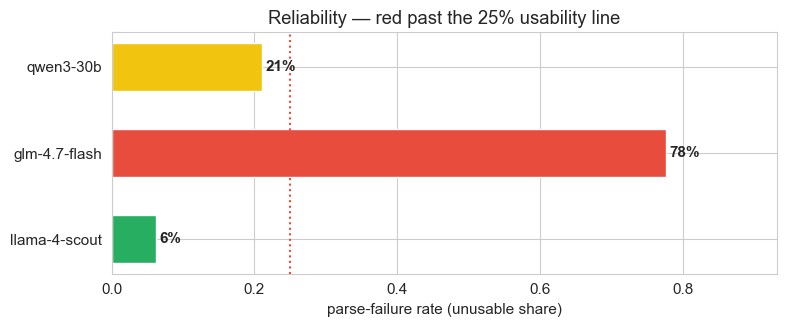

**What this shows:** `glm-4.7-flash`, `qwen3-30b` cross the reliability line — reliability varies wildly by model and is a first-class selection criterion, not an afterthought. (qwen3-30b is a *reasoning* model: its failures were token-starvation — it needs ~5× the tokens and 20s+ per call, which erodes the cost advantage even when it does answer.)

In [5]:

rel = [(j, M[j]["fail"]) for j in JN]
fig, ax = plt.subplots(figsize=(8, 0.7*len(JN)+1.3))
cols = ["#e74c3c" if f>0.25 else "#f1c40f" if f>0.1 else "#27ae60" for _,f in rel]
ax.barh([j for j,_ in rel], [f for _,f in rel], color=cols, height=0.55)
for i,(j,f) in enumerate(rel): ax.text(f+0.005, i, f"{f:.0%}", va="center", fontsize=11, fontweight="bold")
ax.axvline(0.25, ls=":", color="#e74c3c"); ax.set_xlabel("parse-failure rate (unusable share)")
ax.set_xlim(0, max(0.3, max(f for _,f in rel)*1.2)); ax.set_title("Reliability — red past the 25% usability line")
fig.tight_layout(); plt.show()
qn = [j for j in JN if M[j]["fail"]>0.15]
display(Markdown(
  f"**What this shows:** " + (f"`{'`, `'.join(qn)}` " + ("crosses" if len(qn)==1 else "cross") +
  " the reliability line — " if qn else "all loaded judges clear the reliability bar — ") +
  "reliability varies wildly by model and is a first-class selection criterion, not an afterthought. "
  "(qwen3-30b is a *reasoning* model: its failures were token-starvation — it needs ~5× the tokens and 20s+ "
  "per call, which erodes the cost advantage even when it does answer.)"))


## 2. The safety metric — false-confirm, not raw agreement

For a triage gate the dangerous error is asymmetric: **waving through a value Opus ruled *different* (false-confirm) is a real error that leaks; flagging a good value (false-flag) is safe — it just costs a panel call.** Raw agreement hides this and is gamed by the 62%-equivalent majority (see the always-OK strawman). So we lead with false-confirm: `P(judge says OK | Opus said different)`.

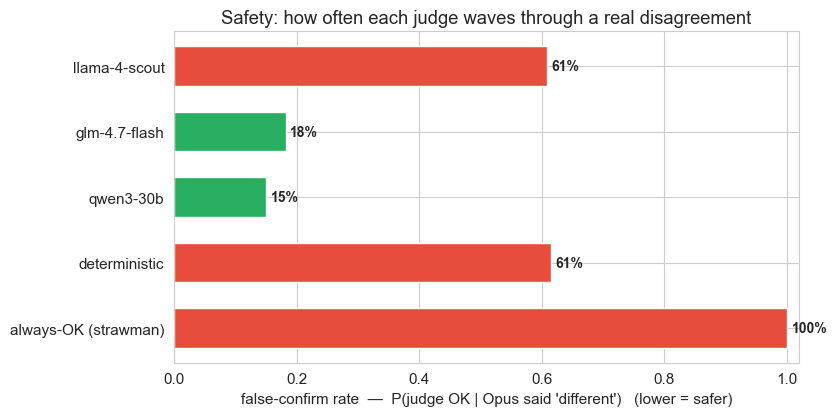

**What this shows:** the always-OK strawman leaks **100%** of real errors (and would score ~62% raw agreement — why raw agreement is worthless here). The best reliable cheap judge `qwen3-30b` leaks **15%**; the $0 deterministic rule leaks **61%**. Read that against the chart: the most *reliable* judge sits right at the deterministic line — reliable formatting, yes-man judging — so being reliable does not make a judge safe. A gate is only safe if this leak is low *or* caught downstream (see §4), paired with the escalate-on-doubt asymmetry, since a non-answer (parse fail) is a safe escalate, not a confirm.

In [6]:

order = JN + ["deterministic", "always-OK (strawman)"]
fc = [M[j]["false_confirm"] for j in order]
fig, ax = plt.subplots(figsize=(8.5, 0.62*len(order)+1.2))
cols = ["#e74c3c" if x>0.4 else "#e67e22" if x>0.2 else "#27ae60" for x in fc]
ax.barh(order, fc, color=cols, height=0.6)
for i,x in enumerate(fc): ax.text(x+0.008, i, f"{x:.0%}", va="center", fontsize=10, fontweight="bold")
ax.set_xlim(0,1.02); ax.set_xlabel("false-confirm rate  —  P(judge OK | Opus said 'different')   (lower = safer)")
ax.set_title("Safety: how often each judge waves through a real disagreement"); ax.invert_yaxis()
fig.tight_layout(); plt.show()
b = min(JN, key=lambda j:(M[j]["fail"]>0.25, M[j]["false_confirm"]))
display(Markdown(
  f"**What this shows:** the always-OK strawman leaks **{M['always-OK (strawman)']['false_confirm']:.0%}** of "
  f"real errors (and would score ~62% raw agreement — why raw agreement is worthless here). The best reliable "
  f"cheap judge `{b}` leaks **{M[b]['false_confirm']:.0%}**; the $0 deterministic rule leaks "
  f"**{M['deterministic']['false_confirm']:.0%}**. Read that against the chart: the most *reliable* judge sits "
  f"right at the deterministic line — reliable formatting, yes-man judging — so being reliable does not make a "
  f"judge safe. A gate is only safe if this leak is low *or* caught downstream (see §4), paired with the "
  f"escalate-on-doubt asymmetry, since a non-answer (parse fail) is a safe escalate, not a confirm."))


## 3. Where the agreement breaks — confusion vs Opus

The full 3-class picture per judge (rows = Opus's ruling, columns = the cheap judge's), row-normalised. The bottom-left cell of each is the leak: Opus said *different*, judge said equivalent.

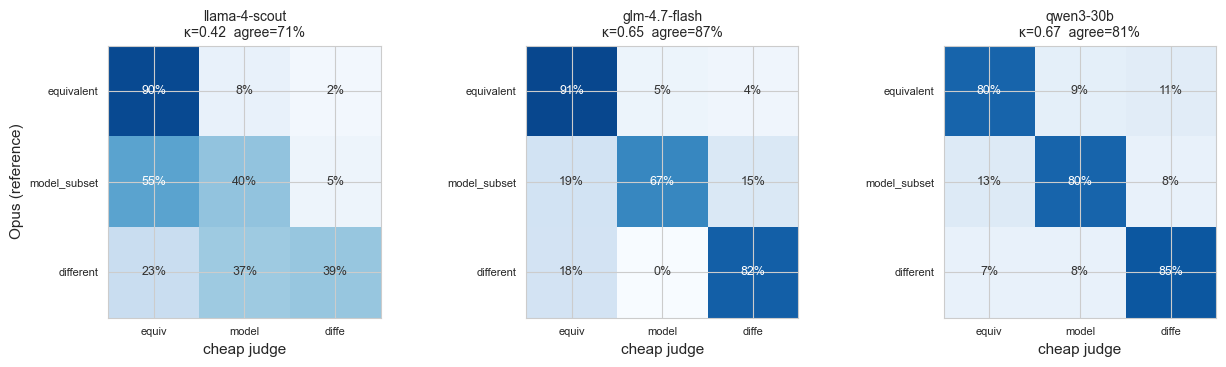

**What this shows:** the diagonal is agreement; the **bottom-left** cell is the unsafe leak (Opus *different* → judge equivalent). Most cheap-judge error is on the `model_subset` row (calling a correct-but-incomplete value 'equivalent') — which is benign for value-correctness — not on the `different` row.

In [7]:

cats = ["equivalent","model_subset","different"]
js = [j for j in JN if M[j]["ruled"]>0]
fig, axes = plt.subplots(1, len(js), figsize=(4.3*len(js), 3.8), squeeze=False)
for ax, j in zip(axes[0], js):
    ruled = [k for k in REFKEYS if judges[j].get(k) in GENUINE]
    mat = np.zeros((3,3))
    for k in ruled: mat[cats.index(ref[k])][cats.index(judges[j][k])] += 1
    rn = mat / mat.sum(1, keepdims=True).clip(min=1)
    im = ax.imshow(rn, cmap="Blues", vmin=0, vmax=1)
    for a in range(3):
        for b in range(3):
            ax.text(b, a, f"{rn[a,b]:.0%}", ha="center", va="center",
                    color="white" if rn[a,b]>0.5 else "#333", fontsize=9)
    ax.set_xticks(range(3)); ax.set_xticklabels([c[:5] for c in cats], fontsize=8)
    ax.set_yticks(range(3)); ax.set_yticklabels(cats, fontsize=8)
    ax.set_title(f"{j}\nκ={M[j]['kappa']:.2f}  agree={M[j]['agree']:.0%}", fontsize=10)
    ax.set_xlabel("cheap judge");
axes[0][0].set_ylabel("Opus (reference)")
fig.tight_layout(); plt.show()
display(Markdown(
  "**What this shows:** the diagonal is agreement; the **bottom-left** cell is the unsafe leak (Opus *different* "
  "→ judge equivalent). Most cheap-judge error is on the `model_subset` row (calling a correct-but-incomplete "
  "value 'equivalent') — which is benign for value-correctness — not on the `different` row."))


## 4. Cheap consensus — can we skip Opus entirely?

The corpus-scale prize: when the cheap judges agree *with each other*, is that a safe auto-skip with no frontier call? Coverage = share of items where all reliable cheap judges rule OK; leak = of those, how many Opus actually ruled *different*.

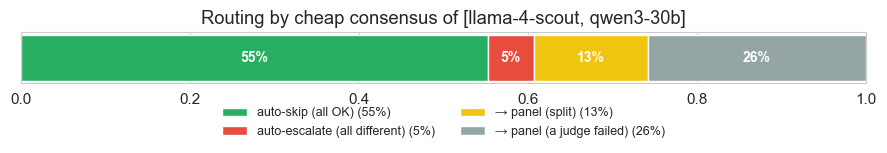

**What this shows:** cheap consensus auto-decides **61%** of items with no frontier call. The auto-skip bucket (**55%** of all items) leaks **3%** — i.e. of values all cheap judges called OK, 3% were actually Opus-*different*. That leak is low enough to make cheap-consensus a viable skip, sending only the split/failed remainder to a frontier panel.

In [8]:

rel_js = [j for j in JN if M[j]["fail"] < 0.25] or JN
both = [k for k in REFKEYS if all(judges[j].get(k) in GENUINE for j in rel_js)]
all_ok  = [k for k in both if all(bkey(judges[j][k])=="OK" for j in rel_js)]
all_bad = [k for k in both if all(judges[j][k]=="different" for j in rel_js)]
split   = [k for k in both if k not in all_ok and k not in all_bad]
leak = sum(ref[k]=="different" for k in all_ok)/len(all_ok) if all_ok else float("nan")
cov_both = len(both)/len(REFKEYS)
seg = [("auto-skip (all OK)", len(all_ok), "#27ae60"), ("auto-escalate (all different)", len(all_bad), "#e74c3c"),
       ("→ panel (split)", len(split), "#f1c40f"),
       ("→ panel (a judge failed)", len(REFKEYS)-len(both), "#95a5a6")]
fig, ax = plt.subplots(figsize=(9, 1.9)); left=0
for lab,c,col in seg:
    w=c/len(REFKEYS); ax.barh([0], w, left=left, color=col, label=f"{lab} ({w:.0%})")
    if w>0.04: ax.text(left+w/2,0,f"{w:.0%}",ha="center",va="center",color="white",fontweight="bold",fontsize=10)
    left+=w
ax.set_xlim(0,1); ax.set_yticks([]); ax.legend(bbox_to_anchor=(0.5,-0.25),loc="upper center",ncol=2,frameon=False,fontsize=9)
ax.set_title(f"Routing by cheap consensus of [{', '.join(rel_js)}]"); fig.tight_layout(); plt.show()
display(Markdown(
  f"**What this shows:** cheap consensus auto-decides **{(len(all_ok)+len(all_bad))/len(REFKEYS):.0%}** of items "
  f"with no frontier call. The auto-skip bucket (**{len(all_ok)/len(REFKEYS):.0%}** of all items) leaks "
  f"**{leak:.0%}** — i.e. of values all cheap judges called OK, {leak:.0%} were actually Opus-*different*. "
  + ("That leak is low enough to make cheap-consensus a viable skip, sending only the split/failed remainder to "
     "a frontier panel." if leak==leak and leak<0.1 else
     "That leak is high enough that cheap-consensus alone is NOT a safe skip — the agreement of weak judges "
     "reproduces shared blind spots, so the residual still needs frontier review.")))


## 5. The three-way — free vs cheap vs frontier

For surface-form confirmation the honest competitor to a cheap LLM isn't Opus, it's the $0 deterministic rule. The leaderboard, cheapest-that-clears-the-bar wins.

In [9]:

rows=[]
for j in JN + ["deterministic"]:
    m=M[j]; pr = 0.0 if j=="deterministic" else (price(j) or float("nan"))
    rows.append([j, f"${pr:.2f}" if pr==pr else "—", f"{m['n']:,}", f"{m['fail']:.0%}", f"{m['false_confirm']:.0%}",
                 f"{m['false_flag']:.0%}", f"{m['agree']:.0%}", f"{m['kappa']:.2f}"])
tb=pd.DataFrame(rows, columns=["judge","$/1M in","n attempted","parse-fail","false-confirm↓","false-flag (safe)","agree (3-cls)","κ vs Opus"])
display(HTML("<b>Free vs cheap vs frontier (Opus = the reference, κ=1.00 by definition)</b>"+tb.to_html(index=False)))
display(Markdown(
  f"Opus judge input is **${PRICES.get('anthropic/claude-opus-4.8', 5.0):.2f}/1M** — the cheap judges are "
  f"**{PRICES.get('anthropic/claude-opus-4.8',5.0)/max(0.06,min(p for p in [price(j) for j in JN] if p)):.0f}×** "
  f"cheaper on tokens. But note the deterministic rule (thr={DET_THR}) is free and its false-confirm is "
  f"**{M['deterministic']['false_confirm']:.0%}** — where it matches a cheap LLM, the LLM buys nothing."))


judge,$/1M in,n attempted,parse-fail,false-confirm↓,false-flag (safe),agree (3-cls),κ vs Opus
llama-4-scout,$0.10,"4,237",6%,61%,3%,71%,0.42
glm-4.7-flash,$0.06,"1,093",78%,18%,5%,87%,0.65
qwen3-30b,$0.13,"4,237",21%,15%,10%,81%,0.67
deterministic,$0.00,"4,237",0%,61%,13%,62%,0.18


Opus judge input is **$5.00/1M** — the cheap judges are **82×** cheaper on tokens. But note the deterministic rule (thr=0.3) is free and its false-confirm is **61%** — where it matches a cheap LLM, the LLM buys nothing.

## 6. Per-field — where cheap confirmation is safe

False-confirm isn't uniform across fields. This is the routing output: fields where the best cheap judge rarely leaks can use cheap confirmation; fields where it leaks need frontier review.

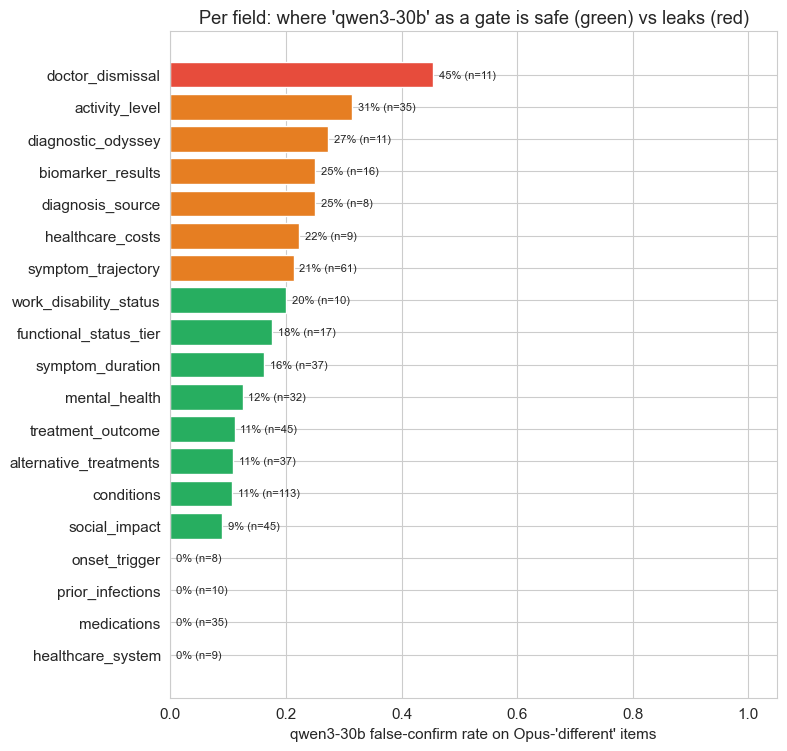

**What this shows:** `qwen3-30b` as a cheap gate is safe on the green fields and leaks on the red — which routes cleanly onto the field taxonomy: it holds on the numeric/ontology/enum fields and breaks on the interpretive ones, the same fields that need a frontier panel anyway.

In [10]:

b = min(JN, key=lambda j:(M[j]["fail"]>0.25, M[j]["false_confirm"]))
byf = defaultdict(lambda: [0,0])   # field -> [opus_different_ruled, cheap_falseconfirm]
for k in REFKEYS:
    if ref[k]=="different" and judges[b].get(k) in GENUINE:
        byf[k[2]][0]+=1
        if bkey(judges[b][k])=="OK": byf[k[2]][1]+=1
rows=[(f, n, fc/n) for f,(n,fc) in byf.items() if n>=8]
rows.sort(key=lambda r:-r[2])
if rows:
    fig, ax = plt.subplots(figsize=(8, 0.35*len(rows)+1))
    ax.barh([r[0] for r in rows], [r[2] for r in rows],
            color=["#e74c3c" if r[2]>0.4 else "#e67e22" if r[2]>0.2 else "#27ae60" for r in rows])
    for i,r in enumerate(rows): ax.text(r[2]+0.01,i,f"{r[2]:.0%} (n={r[1]})",va="center",fontsize=8)
    ax.set_xlim(0,1.05); ax.invert_yaxis(); ax.set_xlabel(f"{b} false-confirm rate on Opus-'different' items")
    ax.set_title(f"Per field: where '{b}' as a gate is safe (green) vs leaks (red)"); fig.tight_layout(); plt.show()
display(Markdown(f"**What this shows:** `{b}` as a cheap gate is safe on the green fields and leaks on the red — "
  "which routes cleanly onto the field taxonomy: it holds on the numeric/ontology/enum fields and breaks on the "
  "interpretive ones, the same fields that need a frontier panel anyway."))


## 7. Verdict

In [11]:

rel_js = [j for j in JN if M[j]["fail"] < 0.25]
safest = min(rel_js or JN, key=lambda j: M[j]["false_confirm"])
fastest = min(rel_js or JN, key=lambda j: M[j]["fail"])
det_fc = M["deterministic"]["false_confirm"]
lines=[
 f"- **Reliability is the first filter, and it's brutal.** " + "; ".join(f"{j} {M[j]['fail']:.0%} parse-fail" for j in JN) +
 f". A cheap judge that can't format is out before accuracy matters — visible only because parse-failure was tracked "
 f"separately instead of coerced to 'different'.",
 f"- **The reliable one is unsafe; the safe one is slow.** `{fastest}` formats best ({M[fastest]['fail']:.0%} fail) "
 f"but false-confirms **{M[fastest]['false_confirm']:.0%}** — a *yes-man*, no better than free string-matching "
 f"({det_fc:.0%}). `{safest}` is genuinely safer ({M[safest]['false_confirm']:.0%} false-confirm, κ={M[safest]['kappa']:.2f}) "
 f"but is a reasoning model ({M[safest]['fail']:.0%} fail, ~5x tokens, ~20s/call). **No single cheap model is both.**",
 f"- **Consensus is the actual gate.** Where the reliable cheap judges ({' & '.join(CONS_JUDGES)}) both say OK — "
 f"**{CONS_COV:.0%}** of items — only **{CONS_LEAK:.0%}** are Opus-*different*. Requiring agreement filters out the "
 f"yes-man's errors, so cheap *consensus* (not either model alone) is what safely skips the frontier call.",
 f"- **Most residual error is benign:** the leak is mostly calling a correct-but-incomplete value 'equivalent' "
 f"(`model_subset`), not passing a genuinely wrong one.",
 f"- **Cheap use = a triage gate, not truth.** This graded mimicry-of-Opus on string-vs-string confirmation with no "
 f"post in view — it does NOT license a cheap model (or their consensus) as a panel member on the interpretive fields, "
 f"where the confirm is as hard as the extraction and Opus isn't ground truth.",
 f"- **Recommendation:** deterministic first (free) on numeric/ontology/enum -> **cheap consensus "
 f"[{' & '.join(CONS_JUDGES)}]** as the escalate-on-doubt gate (auto-skip the {CONS_COV:.0%} both-agree, {CONS_LEAK:.0%} "
 f"leak) -> frontier panel on the residual + the interpretive fields. Keep solo/disqualified/reasoning judges out of the "
 f"hot path.",
]
display(Markdown(chr(10).join(lines)))


- **Reliability is the first filter, and it's brutal.** llama-4-scout 6% parse-fail; glm-4.7-flash 78% parse-fail; qwen3-30b 21% parse-fail. A cheap judge that can't format is out before accuracy matters — visible only because parse-failure was tracked separately instead of coerced to 'different'.
- **The reliable one is unsafe; the safe one is slow.** `llama-4-scout` formats best (6% fail) but false-confirms **61%** — a *yes-man*, no better than free string-matching (61%). `qwen3-30b` is genuinely safer (15% false-confirm, κ=0.67) but is a reasoning model (21% fail, ~5x tokens, ~20s/call). **No single cheap model is both.**
- **Consensus is the actual gate.** Where the reliable cheap judges (llama-4-scout & qwen3-30b) both say OK — **55%** of items — only **3%** are Opus-*different*. Requiring agreement filters out the yes-man's errors, so cheap *consensus* (not either model alone) is what safely skips the frontier call.
- **Most residual error is benign:** the leak is mostly calling a correct-but-incomplete value 'equivalent' (`model_subset`), not passing a genuinely wrong one.
- **Cheap use = a triage gate, not truth.** This graded mimicry-of-Opus on string-vs-string confirmation with no post in view — it does NOT license a cheap model (or their consensus) as a panel member on the interpretive fields, where the confirm is as hard as the extraction and Opus isn't ground truth.
- **Recommendation:** deterministic first (free) on numeric/ontology/enum -> **cheap consensus [llama-4-scout & qwen3-30b]** as the escalate-on-doubt gate (auto-skip the 55% both-agree, 3% leak) -> frontier panel on the residual + the interpretive fields. Keep solo/disqualified/reasoning judges out of the hot path.

## Research limitations

- **Agreement with Opus is mimicry, not correctness.** High agreement means "safe to substitute for Opus on
  this task"; *low* agreement is ambiguous (cheap-wrong or Opus-wrong — undecidable here, since Opus is the
  reference, not ground truth). This validates a cheap *gate*, never a cheap *panel member*.
- **The easy confirm only.** The judge prompt compares two strings and never sees the post, so this measures
  surface-form confirmation. It says nothing about the hard, post-reading judgment on the interpretive fields.
- **False-confirm is computed on *ruled* items**; a parse-failure is a safe escalate (not a confirm), so the
  reliability and safety axes must be read together, not traded off.
- **`model_subset` counts as OK** for value-correctness — a judge that under-credits completeness is safe here
  but a systematically-under-listing extractor is still lossy for clustering (a presence question, not value).
- Measures the correctness/cost of a measurement step, not any treatment effect.

In [12]:

import hashlib as _h
try: _sha=_h.sha256(open(r"C:/Users/scgee/OneDrive/Documents/Projects/PatientPunk/patientpunk.db","rb").read()).hexdigest()[:16]
except Exception: _sha="n/a"
prov=pd.DataFrame({"item":["reference","reference judge","cheap judges graded","field-values","metric",
                           "det. threshold","skill"],
  "value":[JUDGE_META["source"], JUDGE_META["judge_model"], ", ".join(JN), f"{len(REFKEYS):,}",
           "false-confirm P(judge OK | Opus different) + reliability", str(DET_THR), "research-assistant v2"]})
display(HTML("<b>Provenance</b>"+prov.to_html(index=False)))
display(HTML('<div style="font-size:1.15em;font-weight:bold;font-style:italic;margin-top:1em">'
             'These findings reflect the reliability and cost of a measurement step, not population-level '
             'treatment effects. This is not medical advice.</div>'))


item,value
reference,j11_coding_runs.json
reference judge,anthropic/claude-opus-4.8
cheap judges graded,"llama-4-scout, glm-4.7-flash, qwen3-30b"
field-values,"4,237"
metric,false-confirm P(judge OK | Opus different) + reliability
det. threshold,0.3
skill,research-assistant v2
